# Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv")

# Data Exploration Functions

In [3]:
df.head(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
df.tail(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [5]:
df.sample(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
998,15,male,7.8,Both,4.2,2.1,3.42,0.0,low,10,7,9,1
1094,17,male,3.5,Both,4.6,0.7,3.90,0.6,high,7,3,1,0
32,16,male,2.7,Instagram,4.2,2.4,3.05,0.2,high,1,8,4,0
373,16,female,5.7,Both,4.2,1.4,2.56,0.1,high,4,3,1,0
182,15,male,1.6,Instagram,6.9,2.3,3.16,0.9,medium,3,1,5,0


In [6]:
df.shape

(1200, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [10]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [11]:
df.corr(numeric_only = True)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


# Data Visualization

<Axes: xlabel='depression_label', ylabel='count'>

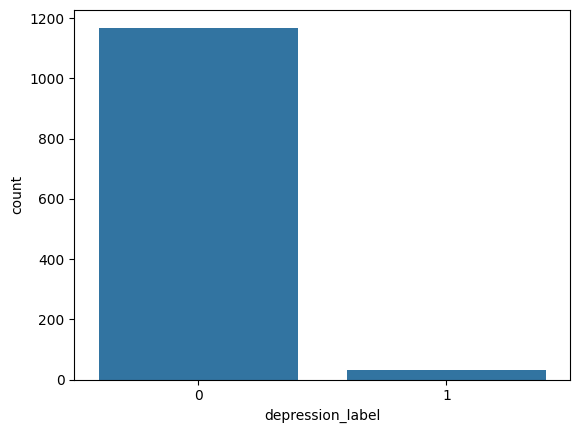

In [12]:
sns.countplot(
    data = df,
    x = "depression_label",
    
)

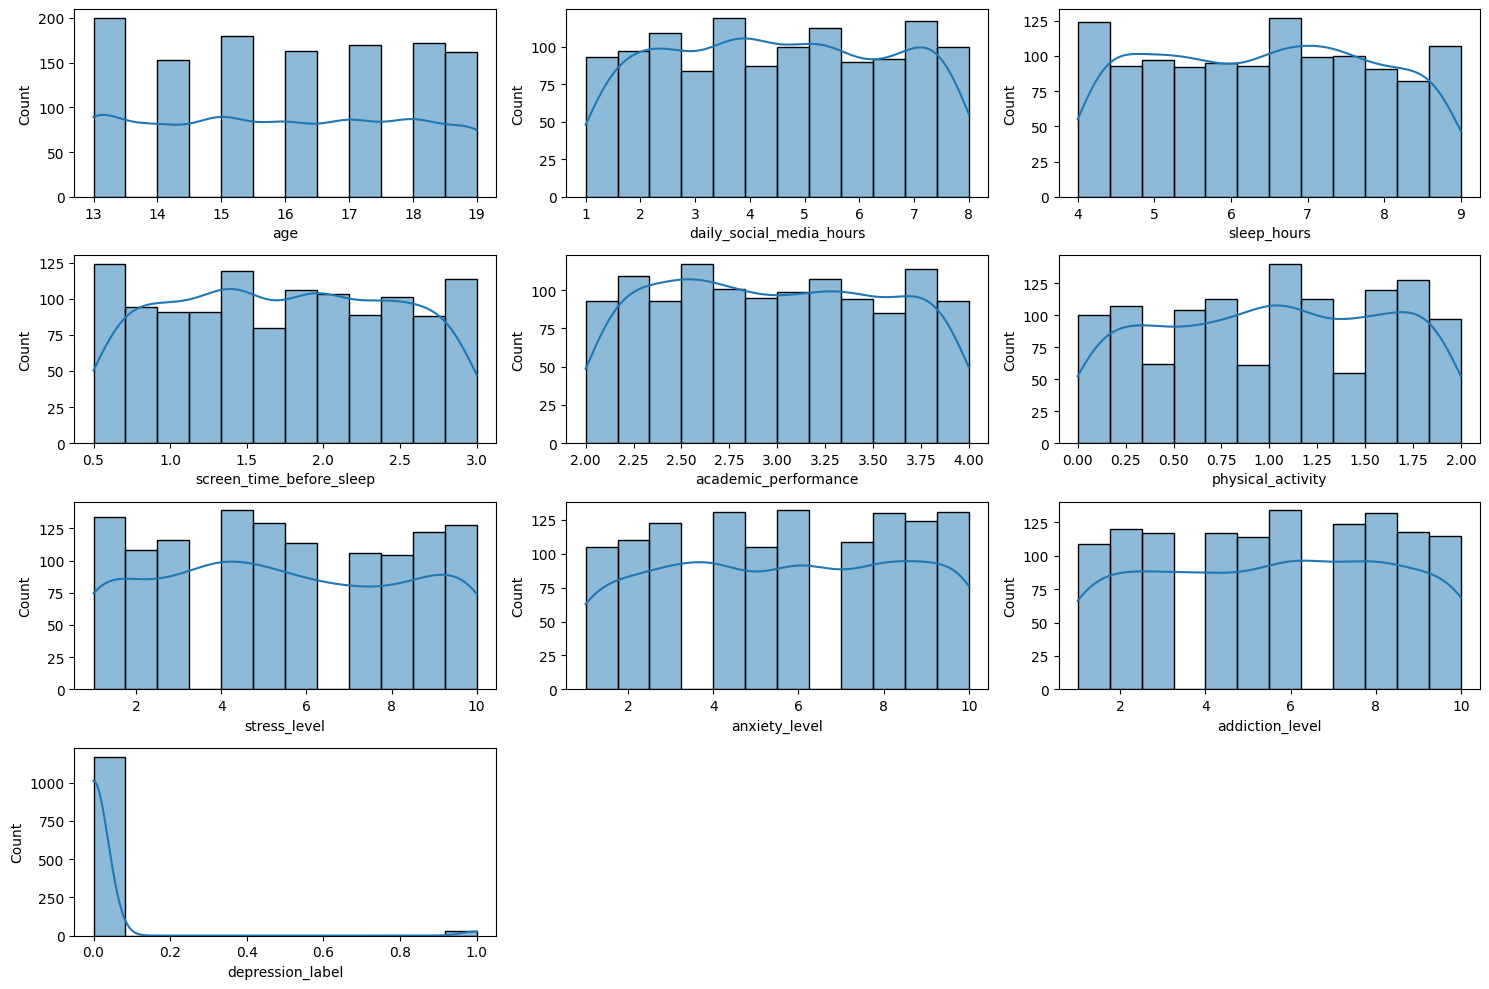

In [13]:
# histplot distribution among numerical columns

num_cols = df.select_dtypes(include = ["int64",'float']).columns
plt.figure(figsize = (15,10))

for i,col in enumerate(num_cols,1):
    plt.subplot(4,3,i)
    sns.histplot(df[col],kde = True)
plt.tight_layout()
plt.show()
    

# Histogram (with KDE) Insights

Age: Age is evenly distributed with no noticeable skewness or outliers.

Daily Social Media Hours: Social media usage hours are uniformly distributed across the dataset.

Sleep Hours: Sleep duration shows a balanced distribution without significant skewness.
Screen Time Before Sleep: Screen time before sleep is fairly evenly distributed with no extreme values.

Academic Performance: Academic performance is consistently distributed across the observed range.

Physical Activity: Physical activity consists of discrete levels with a balanced frequency.

Stress Level: Stress levels are evenly spread across all ratings.

Anxiety Level: Anxiety levels exhibit a balanced and approximately symmetric distribution.

Addiction Level: Addiction scores are uniformly distributed with no obvious distributional issues.

Depression Label: The target variable is highly imbalanced, with class 0 occurring much more frequently than class 1.

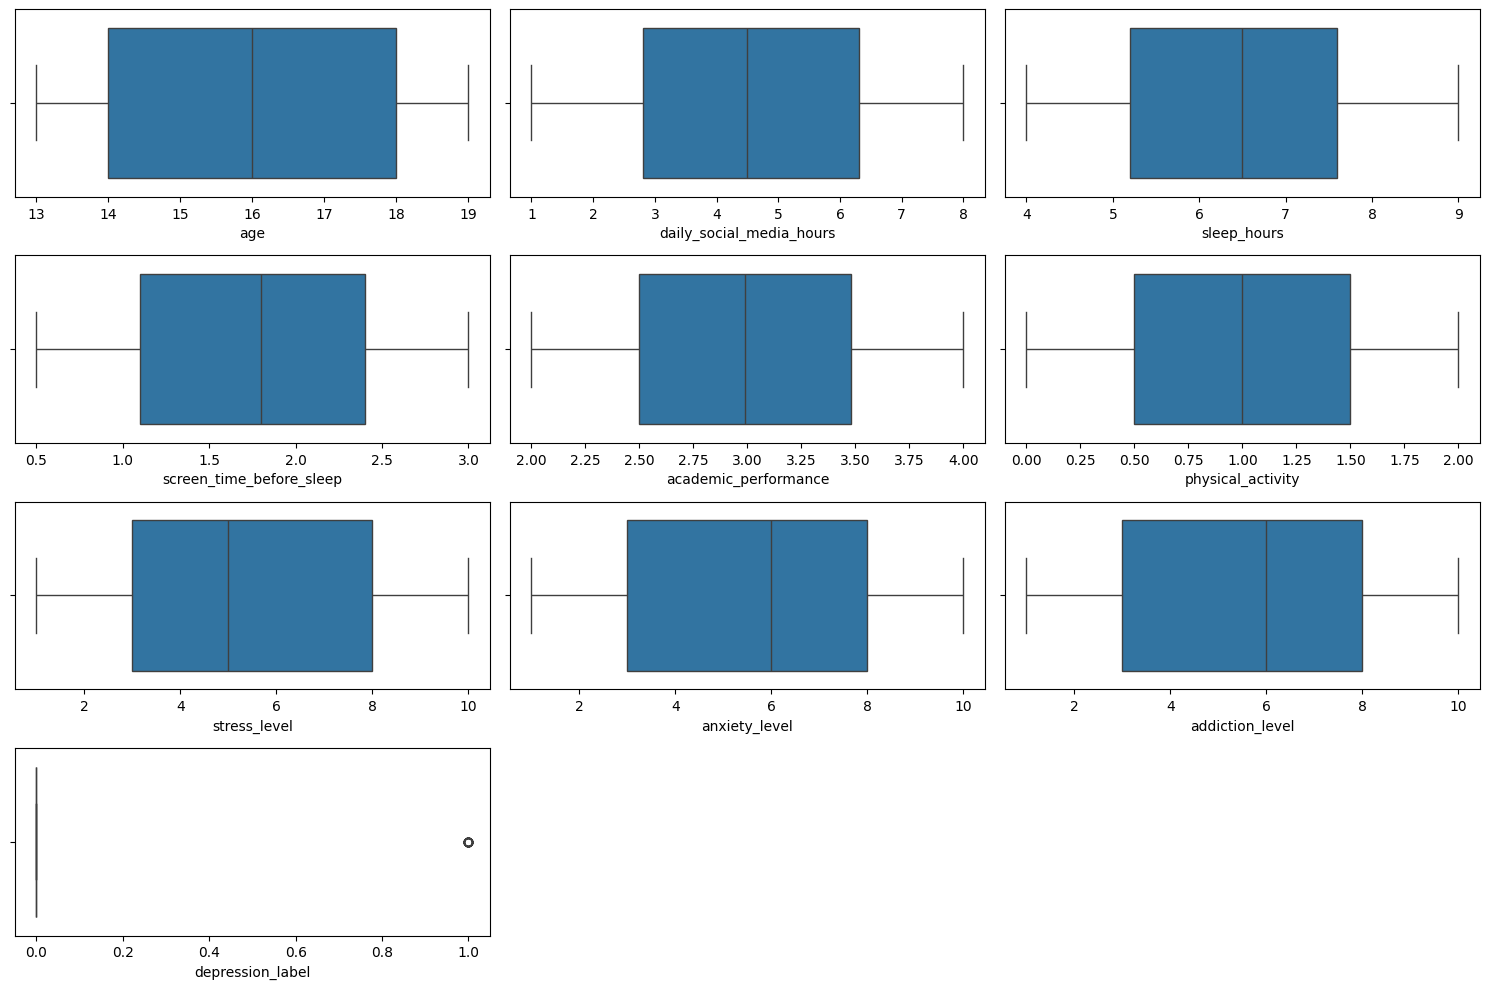

In [14]:
#boxplot distribution among numerical columns
 
num_cols = df.select_dtypes(include = 'number').columns
plt.figure(figsize = (15,10))

for i,col in enumerate(num_cols,1):
    plt.subplot(4,3,i)
    sns.boxplot(x = df[col])

plt.tight_layout()
plt.show()
    

# Boxplot Insights
Age: No outliers are detected, indicating a stable age distribution.

Daily Social Media Hours: The feature shows a moderate spread with no significant outliers.

Sleep Hours: Sleep hours have a balanced distribution without extreme observations.

Screen Time Before Sleep: No potential outliers are observed in screen time before sleep.

Academic Performance: Academic performance shows low variability and no outliers.

Physical Activity: Physical activity contains no meaningful outliers due to its discrete nature.

Stress Level: Stress levels have a moderate spread with no extreme values.

Anxiety Level: Anxiety levels show no evidence of outliers.

Addiction Level: Addiction levels are well distributed with no significant outliers.

Depression Label: The apparent outlier is expected because the target is a binary and highly imbalanced variable, not because of erroneous data.

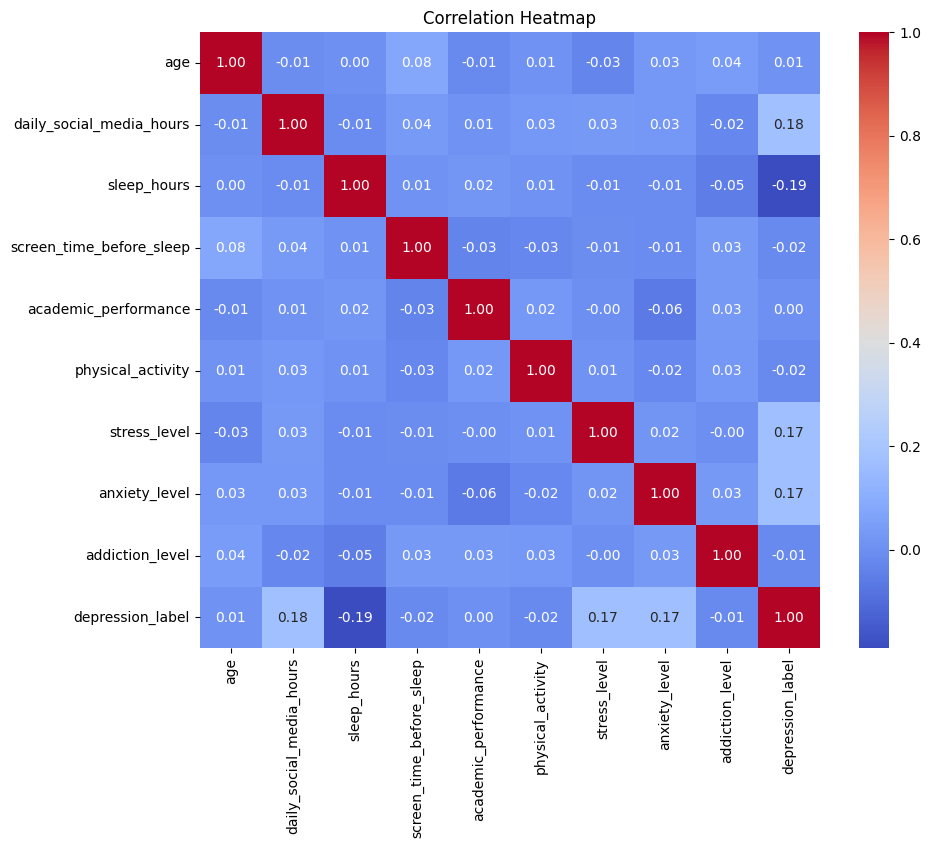

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Heatmap Insight

Most numerical features show very weak correlations with one another, indicating low multicollinearity in the dataset. The target depression_label has a weak positive correlation with daily_social_media_hours (0.18), stress_level (0.17), and anxiety_level (0.17), while sleep_hours shows a weak negative correlation (-0.19).

In [16]:
# Checking skewness
num_cols = df.select_dtypes(include = ["int64","float"]).columns
skew_df = pd.DataFrame({
    "columns" : num_cols,
    "skewness" : [df[col].skew()for col in num_cols]
})

print(skew_df)

                    columns  skewness
0                       age  0.017215
1  daily_social_media_hours  0.009172
2               sleep_hours  0.016816
3  screen_time_before_sleep  0.010946
4      academic_performance  0.043702
5         physical_activity -0.054842
6              stress_level  0.047630
7             anxiety_level -0.036251
8           addiction_level -0.042440
9          depression_label  5.985460


# Skewness Insight

Almost all numerical features have skewness values very close to 0 (between -0.06 and 0.05), indicating that their distributions are approximately symmetric with little to no skewness.

Only the target variable depression_label has a high positive skewness (5.99) because it is a binary and imbalanced variable, so its skewness is not interpreted like continuous numerical features.

In [17]:
# Categorical count

cat_cols = df.select_dtypes(include = ["object","category"]).columns
for col in cat_cols:
    display(
        df[col].value_counts().rename_axis(col).reset_index(name = "Count")
    )

,gender,Count
0,male,615
1,female,585


,platform_usage,Count
0,Instagram,411
1,TikTok,398
2,Both,391


,social_interaction_level,Count
0,medium,416
1,low,415
2,high,369


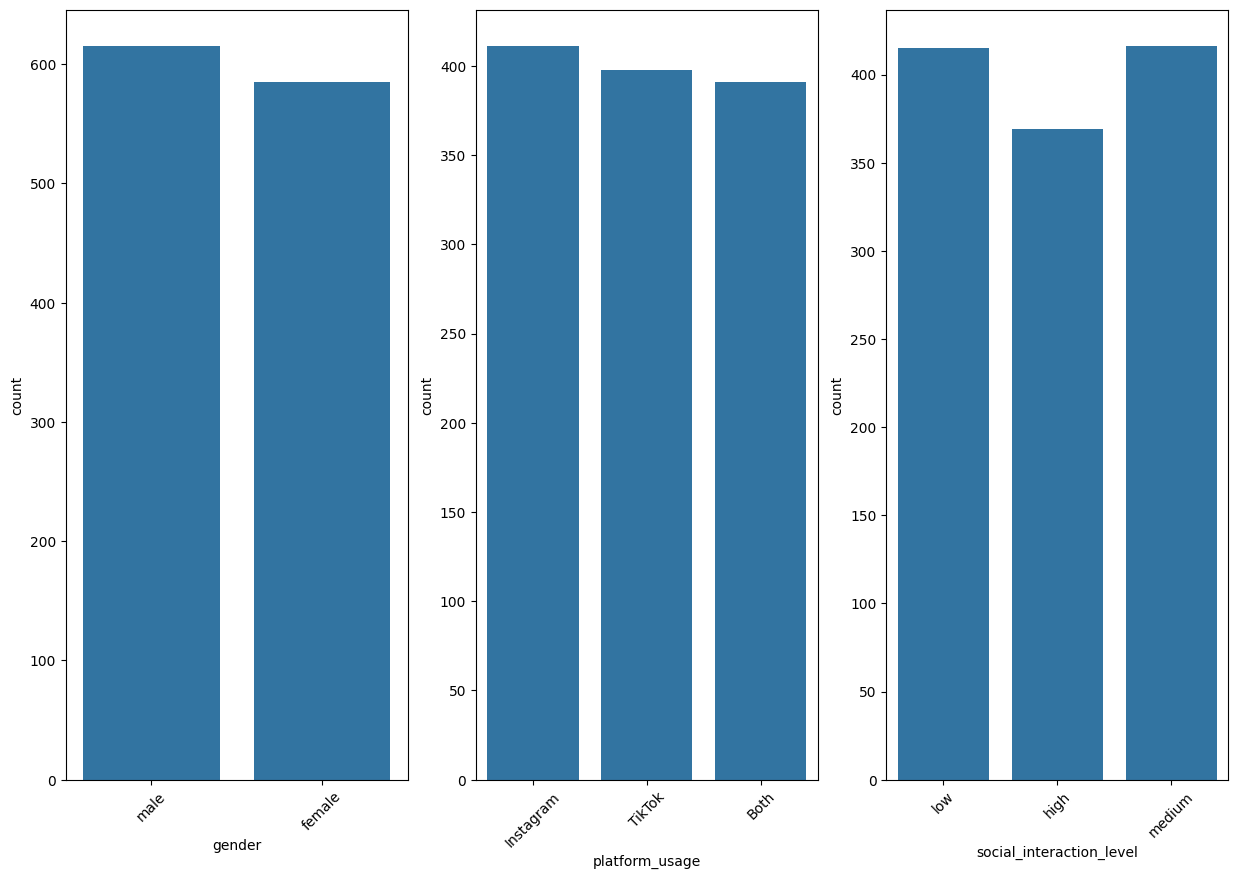

In [18]:
# Countplot distribution among categorical 

cat_cols = df.select_dtypes(include = ["object","category"]).columns
plt.figure(figsize = (15,10))

for i,col in enumerate(cat_cols,1):
    plt.subplot(1,3,i)
    sns.countplot(x = df[col])
    plt.xticks(rotation = 45)


# Insight
Most categorical features have relatively balanced class distributions, suggesting the dataset is well distributed and unlikely to introduce significant class imbalance from these variables.

<Axes: xlabel='depression_label', ylabel='daily_social_media_hours'>

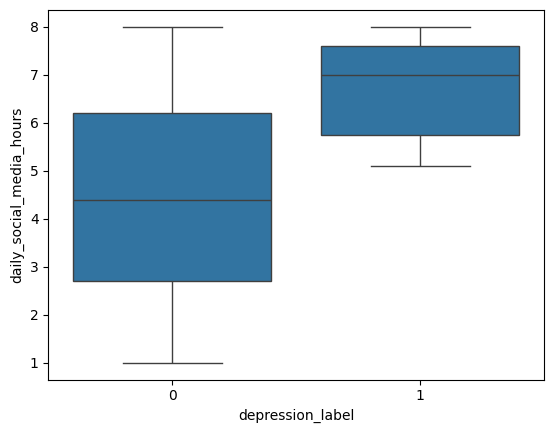

In [19]:
#Boxplot - daily_social_media_hours vs depression_label

sns.boxplot(
    data=df,
    x="depression_label",
    y="daily_social_media_hours"
)

# Insight 
Participants with depression (depression_label = 1) tend to spend more hours on social media daily than those without depression. The median social media usage is noticeably higher for the depressed group.

<Axes: xlabel='platform_usage', ylabel='count'>

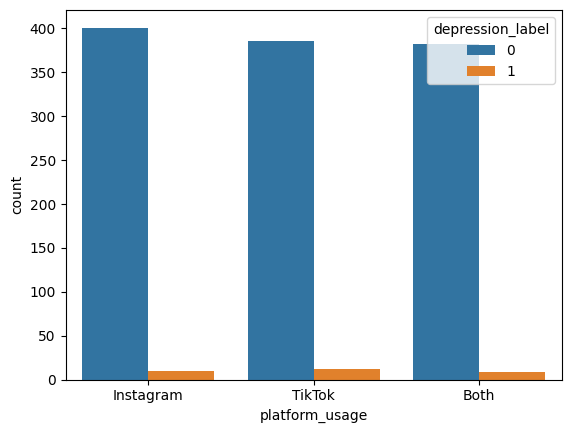

In [20]:
sns.countplot(
    data=df,
    x="platform_usage",
    hue="depression_label",
    )

# Insight 
The majority of users in each platform category do not have depression. The number of depressed users appears relatively similar across Instagram, TikTok, and Both, no platform alone is strongly associated with depression.